In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use("seaborn-v0_8-colorblind")  
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14

### Age Group vs Heart Disease Rate (Bar Chart)

In [ ]:
age_df = pd.read_csv("../data/processed/age_group_stats.csv", sep=",", header=None,
                     names=["age_group", "total", "heart_cases", "heart_rate_pct"])
print(age_df)

  age_group  total  heart_cases  heart_rate_pct
0  Under 40     57           42           73.68
1     40-54    419          276           65.87
2     55-64    411          141           34.31
3       65+    138           67           48.55


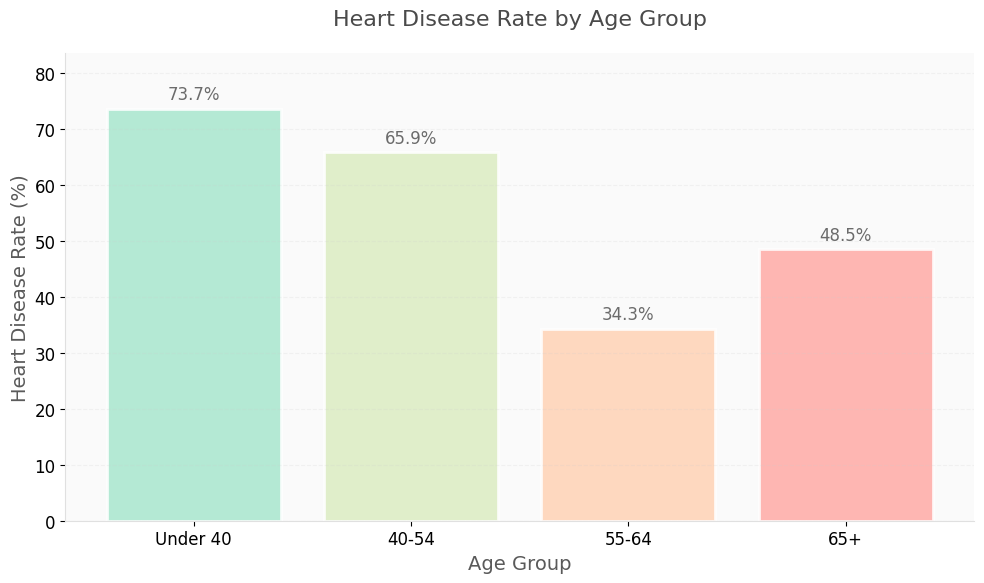

In [11]:
# Set pastel style
plt.style.use('seaborn-v0_8-pastel')
plt.rcParams['axes.facecolor'] = '#FAFAFA'  # Light gray background

# Pastel color scheme
colors = ["#A8E6CE", "#DCEDC2", "#FFD3B5", "#FFAAA6"]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(age_df["age_group"], age_df["heart_rate_pct"],
               color=colors,
               edgecolor='white',  # White border
               linewidth=2,
               alpha=0.85)

plt.xlabel("Age Group", fontsize=14, color="#5A5A5A")
plt.ylabel("Heart Disease Rate (%)", fontsize=14, color="#5A5A5A")
plt.title("Heart Disease Rate by Age Group", 
          fontsize=16, color="#4A4A4A", pad=20)

# Add labels
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 1,
             f"{y:.1f}%", ha="center", va="bottom",
             fontsize=12, color="#6B6B6B")

plt.ylim(0, max(age_df["heart_rate_pct"]) + 10)
plt.grid(axis='y', alpha=0.2, linestyle='--', color='#CCCCCC')

# Remove top and right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E0E0E0')
ax.spines['bottom'].set_color('#E0E0E0')

plt.tight_layout()
plt.show()

### Age group and sex vs Heart Disease Rate (Bar & Line Chart)

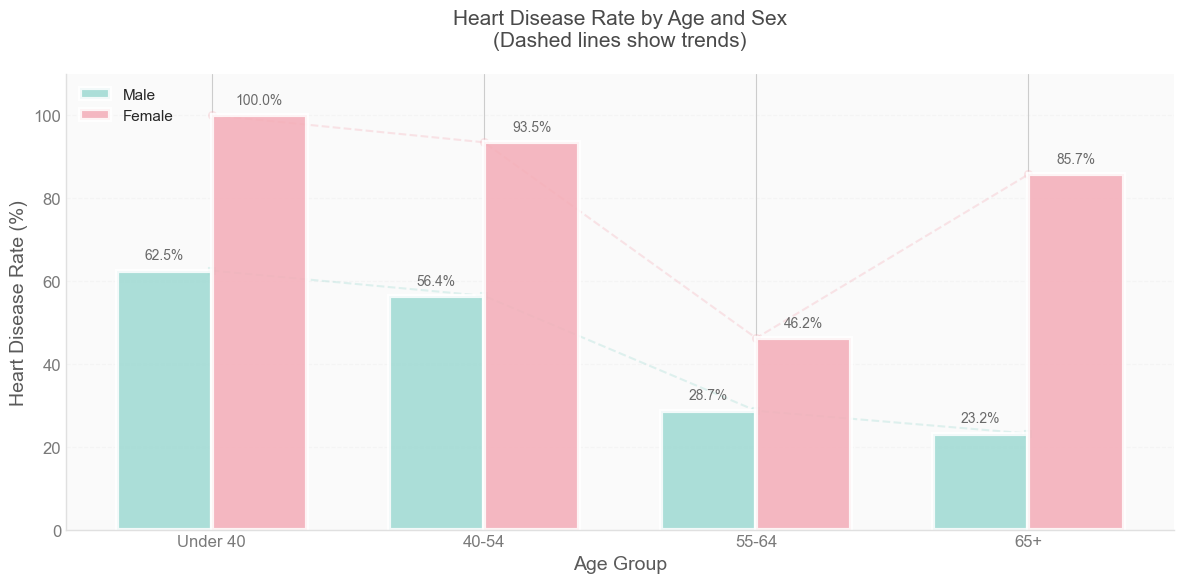

In [ ]:
df = pd.read_csv('../data/processed/age_sex_stats.csv', 
                 names=['age_group', 'sex', 'total', 'heart_cases', 'heart_rate_pct'])
df['sex_label'] = df['sex'].map({0: 'Female', 1: 'Male'})

macaron_colors = {'Male': '#9DD9D2', 'Female': '#F4ACB7'}

age_order = ['Under 40', '40-54', '55-64', '65+']
male_data = []
female_data = []

for age in age_order:
    male_data.append(df[(df['age_group']==age) & (df['sex']==1)]['heart_rate_pct'].values[0])
    female_data.append(df[(df['age_group']==age) & (df['sex']==0)]['heart_rate_pct'].values[0])

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.facecolor'] = '#FAFAFA'

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(age_order))
width = 0.35

# Bar chart (main visual)
bars1 = ax.bar(x - width/2, male_data, width,
                label='Male', color=macaron_colors['Male'],
                edgecolor='white', linewidth=3, alpha=0.85, zorder=2)

bars2 = ax.bar(x + width/2, female_data, width,
                label='Female', color=macaron_colors['Female'],
                edgecolor='white', linewidth=3, alpha=0.85, zorder=2)

# Trend lines (auxiliary, subtle)
ax.plot(x, male_data, 
         color=macaron_colors['Male'], linewidth=1.5, alpha=0.3, 
         linestyle='--', marker='s', markersize=5,
         markerfacecolor='white', markeredgecolor=macaron_colors['Male'],
         markeredgewidth=1.5, zorder=1)

ax.plot(x, female_data, 
         color=macaron_colors['Female'], linewidth=1.5, alpha=0.3,
         linestyle='--', marker='o', markersize=5,
         markerfacecolor='white', markeredgecolor=macaron_colors['Female'],
         markeredgewidth=1.5, zorder=1)

# Value labels (only on bars)
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
            f'{height:.1f}%', ha='center', va='bottom',
            fontsize=10, color='#6A6A6A')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
            f'{height:.1f}%', ha='center', va='bottom',
            fontsize=10, color='#6A6A6A')

ax.set_xlabel('Age Group', fontsize=14, color='#5A5A5A')
ax.set_ylabel('Heart Disease Rate (%)', fontsize=14, color='#5A5A5A')
ax.set_title('Heart Disease Rate by Age and Sex\n(Dashed lines show trends)', 
              fontsize=15, color='#4A4A4A', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_order, fontsize=12)
ax.legend(frameon=False, loc='upper left', fontsize=11)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.12, linestyle='--', color='#CCCCCC', zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E0E0E0')
ax.spines['bottom'].set_color('#E0E0E0')
ax.tick_params(colors='#7A7A7A')

plt.tight_layout()
plt.show()

### Sex vs Heart Disease Rate (Bar Chart)

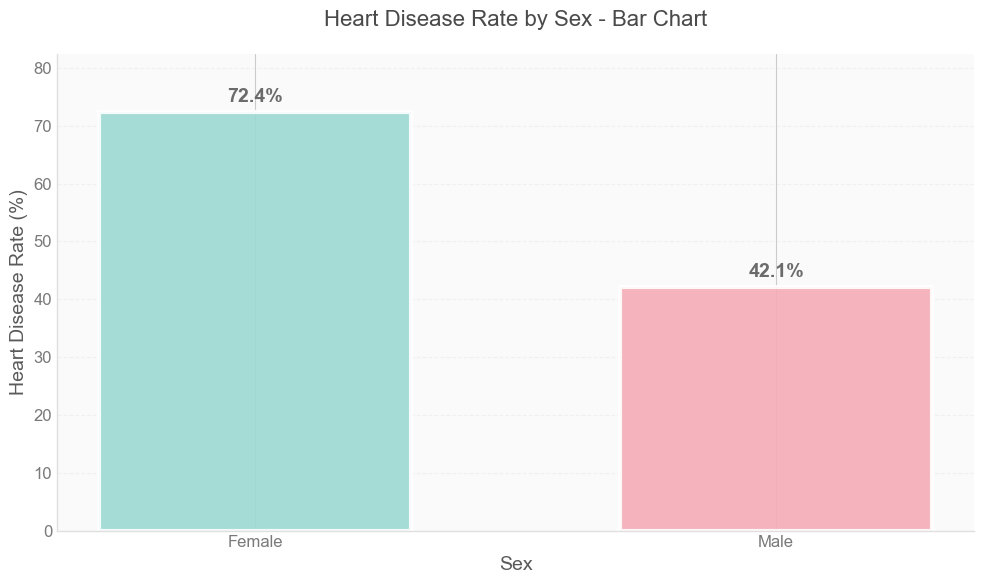

In [13]:
sex_df = pd.read_csv("../data/processed/sex_stats.csv", sep=",", header=None,
                     names=["sex", "total", "heart_cases", "heart_rate_pct"])
sex_df["sex_label"] = sex_df["sex"].map({0: "Female", 1: "Male"})
macaron_colors = ["#F4ACB7", "#9DD9D2", "#FFF1AF", "#D5B9FF"]

# Gender-specific color scheme (select 2 from macaron color palette)
gender_colors = {
    'Male': "#9DD9D2",    # Tiffany blue (Male)
    'Female': "#F4ACB7"   # Rose pink (Female)
}

# Set global style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.facecolor'] = '#FAFAFA'
plt.rcParams['figure.facecolor'] = '#FFFFFF'


plt.figure(figsize=(10, 6))

bars = plt.bar(sex_df["sex_label"], sex_df["heart_rate_pct"],
               color=[gender_colors['Male'], gender_colors['Female']],
               edgecolor='white',
               linewidth=3,
               alpha=0.9,
               width=0.6)

plt.xlabel("Sex", fontsize=14, color="#5A5A5A", fontweight='normal')
plt.ylabel("Heart Disease Rate (%)", fontsize=14, color="#5A5A5A", fontweight='normal')
plt.title("Heart Disease Rate by Sex - Bar Chart", 
          fontsize=16, color="#4A4A4A", fontweight='normal', pad=20)

# Add labels
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 1,
             f"{y:.1f}%", ha="center", va="bottom", 
             fontsize=14, color="#6B6B6B", fontweight='bold')

plt.ylim(0, max(sex_df["heart_rate_pct"]) + 10)
plt.grid(axis='y', alpha=0.2, linestyle='--', linewidth=0.8, color='#CCCCCC')

# Beautify borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E0E0E0')
ax.spines['bottom'].set_color('#E0E0E0')
ax.tick_params(colors='#7A7A7A')

plt.tight_layout()
plt.show()


### Risk Level Distribution (Pie Chart)

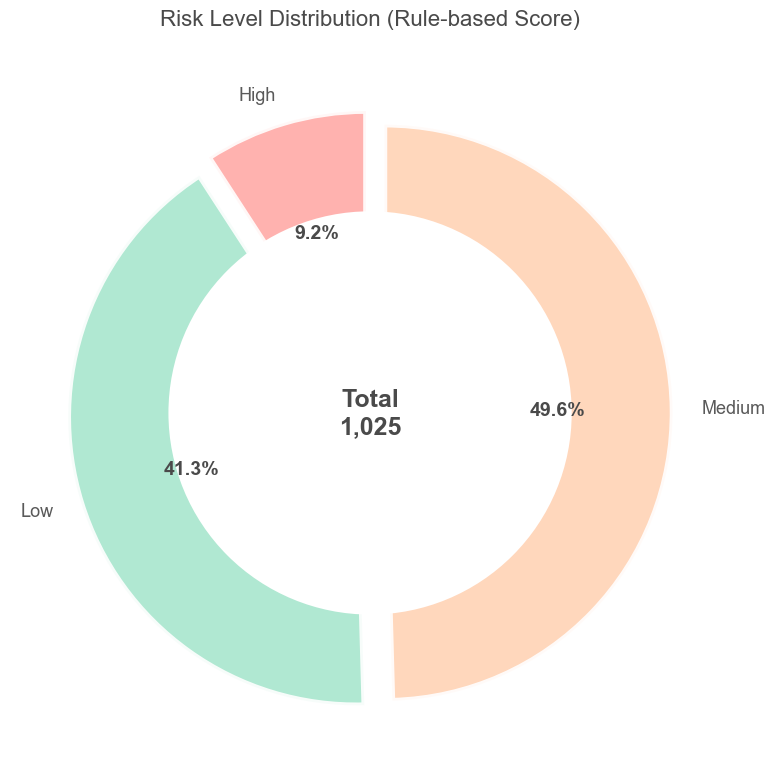

In [ ]:

# Read data
risk_df = pd.read_csv("../data/processed/risk_level_stats.csv", sep=",", header=None,
                      names=["risk_level", "total"])

# Macaron color scheme
macaron_risk_colors = {
    'Low': '#A8E6CE',
    'Medium': '#FFD3B5',
    'High': '#FFAAA6'
}

colors = [macaron_risk_colors[level] for level in risk_df['risk_level']]

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.facecolor'] = '#FAFAFA'

plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(
    risk_df["total"],
    labels=risk_df["risk_level"],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 4, 'alpha': 0.9},
    textprops={'fontsize': 13, 'color': '#5A5A5A'},
    explode=(0.05, 0.05, 0.05)
)

# Key fix: use dark color for percentages!
for autotext in autotexts:
    autotext.set_color('#4A4A4A')      # Dark gray, clearly visible ✅
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

# Add center circle
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gcf().gca().add_artist(centre_circle)

# Display total in center
total_count = risk_df["total"].sum()
plt.text(0, 0, f'Total\n{total_count:,}',
         ha='center', va='center',
         fontsize=18, color='#4A4A4A', fontweight='bold')

plt.title('Risk Level Distribution (Rule-based Score)',
          fontsize=16, color='#4A4A4A', pad=20)

plt.tight_layout()
plt.show()